In [56]:
import pandas as pd

# Load both files
df_non_expiry = pd.read_csv("Data/20260204_option_minute_prices_non_expiry.csv")
df_expiry     = pd.read_csv("Data/20260205_option_minute_prices_expiry.csv")

# Parse time properly
for df in [df_non_expiry, df_expiry]:
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
    df['minute_end'] = df['minute_end'].astype(str).str.zfill(6)

print("Non-expiry shape:", df_non_expiry.shape)
print("Expiry shape:", df_expiry.shape)
print(df_non_expiry.head())

Non-expiry shape: (8625, 4)
Expiry shape: (8625, 4)
        date minute_end             symbol  last_trade_price
0 2026-02-04     091600      NIFTY26FEBFUT         2575220.0
1 2026-02-04     091600  NIFTY2621025550CE           26215.0
2 2026-02-04     091600  NIFTY2621025600CE           23205.0
3 2026-02-04     091600  NIFTY2621025650CE           20300.0
4 2026-02-04     091600  NIFTY2621025700CE           17675.0


In [57]:
# February 5 - Expiry day data
df_feb05 = df_expiry.copy()

print(f"Successfully loaded expiry day data")
print(f"Shape: {df_feb05.shape}")

display(df_feb05.head())

Successfully loaded expiry day data
Shape: (8625, 4)


,date,minute_end,symbol,last_trade_price
0,2026-02-05,091600,NIFTY26FEBFUT,2578540.0
1,2026-02-05,091600,NIFTY2621025600CE,23115.0
2,2026-02-05,091600,NIFTY2621025650CE,19995.0
3,2026-02-05,091600,NIFTY2621025700CE,17140.0
4,2026-02-05,091600,NIFTY2621025750CE,14535.0


### Step 1: Filter Data and Extract Futures Price
First, we'll filter the DataFrame for options data at 11:00:00 (which corresponds to `minute_end = 110000`). We'll also extract the future price and parse the option symbols to get the strike prices and whether they are Call (CE) or Put (PE) options.

In [58]:
import numpy as np
import pandas as pd
import os

os.chdir(r"C:\Users\COMPUTER WORLD IT\OneDrive\Desktop\Delta Hedging & Adversarial Stock Path Generation Simulator")

# Load expiry day data
df_feb05 = pd.read_csv("Data/20260205_option_minute_prices_expiry.csv")

# Fix data types
df_feb05['minute_end'] = df_feb05['minute_end'].astype(str).str.zfill(6)
df_feb05['date'] = pd.to_datetime(df_feb05['date'].astype(str), format='%Y%m%d')

# Filter for 11 AM — use STRING '110000' not integer
filtered_df = df_feb05[df_feb05['minute_end'] == '110000'].copy()
print(f"Rows at 11 AM: {len(filtered_df)}")

# Extract Future Price
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S = futures_row['last_trade_price'].iloc[0]
    print(f"Future Price (S) at 11 AM: ₹{S/100:.2f}")
else:
    S = None
    print("Future price not found!")

# Filter out futures — keep only options
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()
print(f"Options rows: {len(options_df)}")

# Fixed parse_symbol function
def parse_symbol(symbol):
    try:
        if 'CE' in symbol:
            option_type = 'call'
            strike_part = symbol.split('CE')[0]
            digits_only = ''.join(filter(str.isdigit, strike_part))
            if len(digits_only) >= 5:
                return float(digits_only[-5:]), option_type
        elif 'PE' in symbol:
            option_type = 'put'
            strike_part = symbol.split('PE')[0]
            digits_only = ''.join(filter(str.isdigit, strike_part))
            if len(digits_only) >= 5:
                return float(digits_only[-5:]), option_type
        return None, None
    except:
        return None, None

# Apply parser safely
parsed = options_df['symbol'].apply(parse_symbol)
options_df['strike']      = parsed.apply(lambda x: x[0])
options_df['option_type'] = parsed.apply(lambda x: x[1])

# Drop unparseable rows
options_df.dropna(subset=['strike', 'option_type'], inplace=True)
print(f"Options after parsing: {len(options_df)}")

# Fix strike price (paise to rupees)
options_df['strike'] = options_df['strike'] * 100.0

# Build datetime
options_df['observation_datetime'] = pd.to_datetime(
    df_feb05['date'].astype(str).str[:10].iloc[0] + ' ' + '11:00:00'
)

# Time to expiry
expiration_date = pd.to_datetime('2026-02-05 15:30:00')
options_df['T'] = (
    expiration_date - options_df['observation_datetime']
).dt.total_seconds() / (365.25 * 24 * 3600)

# Risk free rate
r = 0.05

print(f"\nS = {S}")
print(f"T = {options_df['T'].iloc[0]:.6f} years")
print(f"\nSample options:")
display(options_df[['symbol','strike','option_type','last_trade_price','T']].head())

# Convert ALL prices from paise to rupees
S_rupees = S / 100
options_df['strike_rs']          = options_df['strike'] / 100
options_df['last_trade_price_rs'] = options_df['last_trade_price'] / 100

print(f"\nS in rupees: ₹{S_rupees:.2f}")
print(f"Sample strikes in rupees:")
print(options_df['strike_rs'].head())
print(f"Sample option prices in rupees:")
print(options_df['last_trade_price_rs'].head())

Rows at 11 AM: 23
Future Price (S) at 11 AM: ₹25715.10
Options rows: 22
Options after parsing: 22

S = 2571510.0
T = 0.000513 years

Sample options:


,symbol,strike,option_type,last_trade_price,T
2393,NIFTY2621025600CE,2560000.0,call,16790.0,0.000513
2394,NIFTY2621025650CE,2565000.0,call,14115.0,0.000513
2395,NIFTY2621025700CE,2570000.0,call,11770.0,0.000513
2396,NIFTY2621025750CE,2575000.0,call,9725.0,0.000513
2397,NIFTY2621025800CE,2580000.0,call,7990.0,0.000513



S in rupees: ₹25715.10
Sample strikes in rupees:
2393    25600.0
2394    25650.0
2395    25700.0
2396    25750.0
2397    25800.0
Name: strike_rs, dtype: float64
Sample option prices in rupees:
2393    167.90
2394    141.15
2395    117.70
2396     97.25
2397     79.90
Name: last_trade_price_rs, dtype: float64


### Step 2: Define Black-Scholes Model and Greeks Calculation

Next, we'll implement the Black-Scholes formula to calculate option prices and the associated Greeks (Delta, Gamma, Theta). We'll use `scipy.stats.norm` for the cumulative distribution function (CDF).

In [59]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


### Step 3: Define Implied Volatility (IV) Solver

Calculating Implied Volatility (IV) involves finding the volatility that, when plugged into the Black-Scholes formula, yields the observed market price of the option. This requires an iterative method, as there's no direct algebraic solution. We'll use a simple bisection method for this.

In [60]:
def implied_volatility(market_price, S, K, T, r, option_type, 
                       tol=0.0001, max_iter=500, verbose=False):
    """
    Calculate Implied Volatility using Bisection Method.
    
    Parameters:
        market_price : observed option price from NSE
        S            : current futures price (NIFTY)
        K            : strike price
        T            : time to expiry in years
        r            : risk-free rate (0.05)
        option_type  : 'call' or 'put'
        tol          : tolerance for convergence (default 0.0001)
        max_iter     : maximum iterations (default 500)
        verbose      : print debug info (default False)
    
    Returns:
        mid_vol : implied volatility (sigma)
    """
    
    # Step 1 — Handle expired options
    if T <= 0:
        return 0.0
    
    # Step 2 — Check if price is valid
    if market_price <= 0:
        return np.nan
    
    # Step 3 — Set initial bounds for bisection
    low_vol  = 0.001   # 0.1% volatility — absolute minimum
    high_vol = 5.000   # 500% volatility — absolute maximum
    mid_vol  = (low_vol + high_vol) / 2
    
    # Step 4 — Check if solution exists within bounds
    price_low,  _, _, _ = black_scholes(S, K, T, r, low_vol,  option_type)
    price_high, _, _, _ = black_scholes(S, K, T, r, high_vol, option_type)
    
    if market_price < price_low:
        if verbose:
            print(f"Market price {market_price} below minimum BS price {price_low:.4f}")
        return np.nan
    
    if market_price > price_high:
        if verbose:
            print(f"Market price {market_price} above maximum BS price {price_high:.4f}")
        return np.nan
    
    # Step 5 — Bisection loop
    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2
        
        # Calculate BS price at midpoint volatility
        price_mid, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)
        
        # Calculate difference between BS price and market price
        diff = price_mid - market_price
        
        if verbose and i % 50 == 0:
            print(f"Iter {i}: low={low_vol:.4f}, mid={mid_vol:.4f}, "
                  f"high={high_vol:.4f}, diff={diff:.4f}")
        
        # Check convergence
        if abs(diff) < tol:
            if verbose:
                print(f"Converged at iter {i}, IV = {mid_vol:.4f}")
            return mid_vol
        
        # Narrow the bounds
        if diff > 0:
            high_vol = mid_vol  # BS price too high → reduce volatility
        else:
            low_vol = mid_vol   # BS price too low  → increase volatility
    
    # Return best guess if max iterations reached
    return mid_vol

print("Implied Volatility (Bisection) function defined.")

Implied Volatility (Bisection) function defined.


### Step 4: Calculate Implied Volatility for all options

Now, we'll apply the `implied_volatility` function to each option in our filtered DataFrame. We'll add a new column for the calculated IV. We will handle cases where the future price `S` might not be available or where IV calculation fails.

In [61]:
if S is not None:
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(
            row['last_trade_price_rs'],  # market price in rupees
            S_rupees,                    # futures price in rupees
            row['strike_rs'],            # strike in rupees
            row['T'],
            r,
            row['option_type'],
            verbose=False                # turn off verbose to reduce output
        ) if row['T'] > 0 else 0, axis=1
    )
else:
    options_df['implied_volatility'] = np.nan
    print("Cannot calculate IV — S not available")

print(f"\nIV Calculation complete!")
display(options_df[['symbol','strike_rs','option_type',
                     'last_trade_price_rs','implied_volatility']].head(10))


IV Calculation complete!


,symbol,strike_rs,option_type,last_trade_price_rs,implied_volatility
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452364
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471846
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488194
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553
2398,NIFTY2621025850CE,25850.0,call,64.90,0.516178
2399,NIFTY2621025900CE,25900.0,call,52.75,0.530051
2400,NIFTY2621025950CE,25950.0,call,42.60,0.542846
2401,NIFTY2621026000CE,26000.0,call,34.95,0.559509
2402,NIFTY2621026050CE,26050.0,call,27.95,0.570695


### Plot: Implied Volatility

Let's visualize the calculated Implied Volatility against the strike price. This plot often reveals the 'volatility smile' or 'volatility skew,' indicating how market participants perceive future volatility across different strike prices.

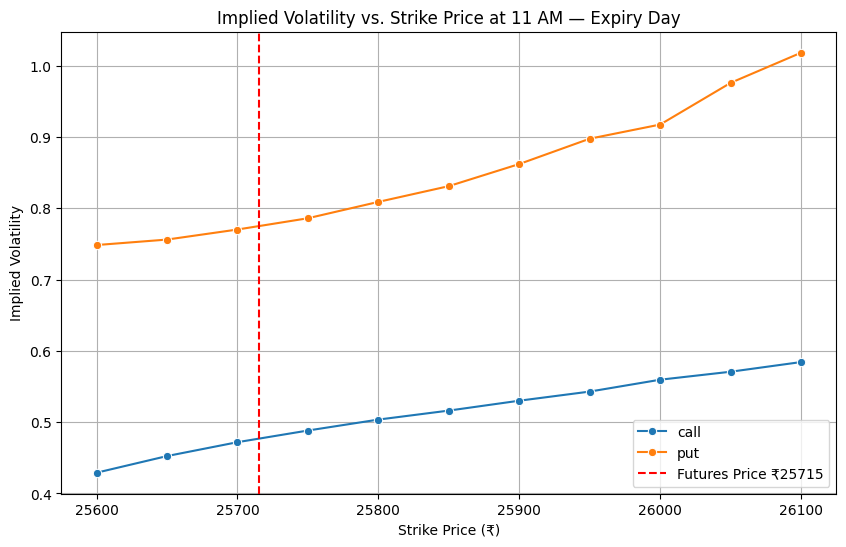

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='implied_volatility', 
             hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Implied Volatility')
plt.axvline(x=S_rupees, color='red', linestyle='--', label=f'Futures Price ₹{S_rupees:.0f}')
plt.legend()
plt.grid(True)
plt.show()

### Step 5: Calculate Greeks for all options using Implied Volatility

With the implied volatility calculated, we can now use it in the Black-Scholes model to derive the Delta, Gamma, and Theta for each option.

In [63]:
if S is not None:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                S_rupees,           # ← rupees not paise
                row['strike_rs'],   # ← rupees not paise
                row['T'],
                r,
                row['implied_volatility'],
                row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility'])
        else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks — S not available.")

print("Greeks calculated!")
display(options_df[['symbol','strike_rs','option_type',
                     'last_trade_price_rs','implied_volatility',
                     'delta','gamma','theta']].head(10))

Greeks calculated!


,symbol,strike_rs,option_type,last_trade_price_rs,implied_volatility,delta,gamma,theta
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009,0.680472,0.001430,-87875.022860
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452364,0.600617,0.001465,-99902.536916
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471846,0.524993,0.001448,-107281.935470
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488194,0.454316,0.001393,-110377.550044
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553,0.389375,0.001307,-110085.946530
2398,NIFTY2621025850CE,25850.0,call,64.90,0.516178,0.330206,0.001204,-106529.246862
2399,NIFTY2621025900CE,25900.0,call,52.75,0.530051,0.278119,0.001086,-101278.206574
2400,NIFTY2621025950CE,25950.0,call,42.60,0.542846,0.232362,0.000966,-94372.010507
2401,NIFTY2621026000CE,26000.0,call,34.95,0.559509,0.194677,0.000845,-87701.031421
2402,NIFTY2621026050CE,26050.0,call,27.95,0.570695,0.160537,0.000733,-79176.633911


### Step 6: Plot Delta

Let's visualize how Delta varies with the strike price for both Call and Put options. Delta measures the sensitivity of the option price to changes in the underlying asset's price.

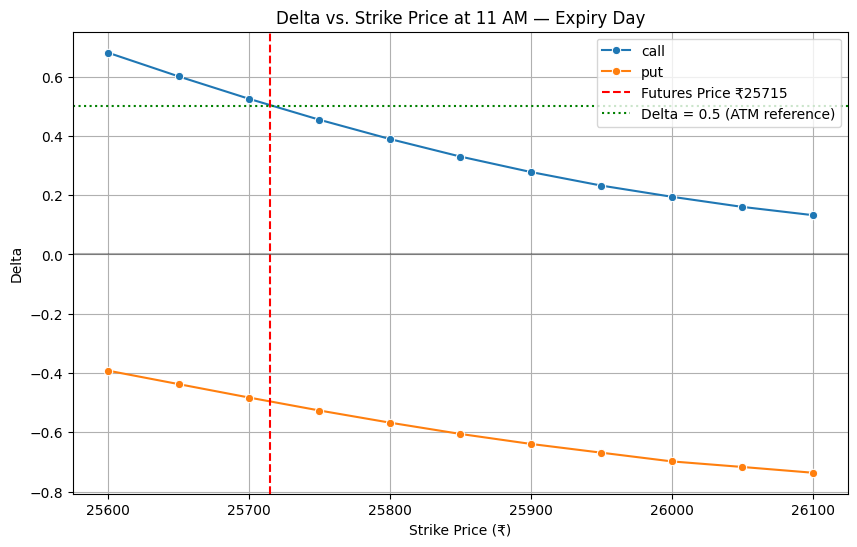

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='delta', 
             hue='option_type', marker='o')

plt.title('Delta vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Delta')
plt.axvline(x=S_rupees, color='red', linestyle='--', 
            label=f'Futures Price ₹{S_rupees:.0f}')
plt.axhline(y=0.5, color='green', linestyle=':', 
            label='Delta = 0.5 (ATM reference)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()